# Estudo da distribuição GLAM-FKML

### Componentes da Distribuição

Estas são as quatro ferramentas estatísticas essenciais para analisarmos o comportamento dos dados na biblioteca:

1. RVS (Amostra Aleatória): É o gerador de dados práticos. Cria uma amostra de valores sintéticos que, quando agrupados em um histograma, mostram onde os dados mais se concentram.

2. PDF (Densidade de Probabilidade): É a curva teórica e suave do histograma. Os picos da curva indicam os valores mais prováveis, enquanto as caudas mostram os eventos mais raros.

3. CDF (Distribuição Acumulada): Mostra a probabilidade somada (em formato de curva que cresce de 0% a 100%). Responde à pergunta: "Qual a chance de obtermos um valor menor ou igual a X?".

4. PPF (Percentil/Ponto Percentual): Faz o exato oposto da CDF. Você fornece uma probabilidade (ex: 90%) e ela te devolve o valor correspondente no eixo X. É a ferramenta ideal para encontrar percentis.

### Os 4 Parâmetros (Lambdas) da FKML
A parametrização FKML é altamente flexível, funcionando como uma distribuição que usa 4 parâmetros para imitar o formato de diversas outras distribuições matemáticas:

$\lambda_1$ (Locação): Define a posição. Apenas move a curva para a esquerda ou para a direita no eixo X, sem alterar o seu formato (similar à média).

$\lambda_2$ (Escala): Define a largura. Controla a dispersão dos dados: estica a curva (deixando-a mais larga e achatada) ou comprime-a (deixando-a mais estreita e pontiaguda).

$\lambda_3$ (Cauda Esquerda): Define o lado esquerdo. Controla o peso e a extensão da cauda esquerda do gráfico.

$\lambda_4$ (Cauda Direita): Define o lado direito. Quando é igual ao $\lambda_3$, a curva é perfeitamente simétrica (como a Normal). Quando são diferentes, a curva ganha assimetria (como a Gumbel).

### Exploração Básica da Distribuição GLAM

Nesta primeira etapa, o objetivo é criar uma distribuição do zero e analisar a sua anatomia. Para isso, vamos:

1. Instanciar o modelo definindo valores arbitrários (de teste) para os quatro Lambdas.
2. Gerar uma amostra sintética de 1000 valores usando o gerador de variáveis aleatórias (`rvs`) e plotar o seu histograma.
3. Mapear as funções matemáticas centrais do modelo, traçando os gráficos da Função Densidade de Probabilidade (**PDF**), Função Distribuição Acumulada (**CDF**) e Percentil/Função Ponto Percentual(**PPF**).

obs: Para todas as etapas deste estudo, iremos usar as seguintes bibliotecas: Numpy, Matplotlib e PyGLAM

In [99]:
import numpy
import matplotlib.pyplot as plt
from pyglam import *

#### 1° Instância: Gráfico exponencial

In [100]:
# 1. Instanciar a distribuição com os lambdas escolhidos
lam1, lam2, lam3, lam4 = 0.00251029, 1.45848339, 2.0, 0.13239563
g = GlamFKML(lam1=lam1, lam2=lam2, lam3=lam3, lam4=lam4)

# 2. Gerar Amostra (RVS)
amostra = g.rvs(size=1000)

# 3. Gerar valores do eixo X para a PDF e CDF
x_vals = np.linspace(min(amostra), max(amostra), 500)

# 4. Calcular PDF e CDF
pdf_vals = g.pdf(x_vals)
cdf_vals = g.cdf(x_vals)

# 5. Calcular Percentis (PPF)
q_vals = np.linspace(0.01, 0.99, 100)
ppf_vals = g.ppf(q_vals)

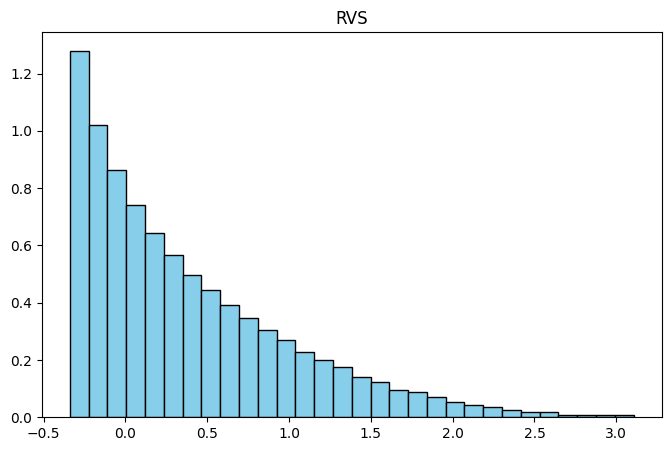

In [101]:
plt.figure(figsize=(8, 5))
plt.hist(amostra, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('RVS')

plt.savefig('01_histograma_amostra.png', dpi=300, bbox_inches='tight')

plt.show()

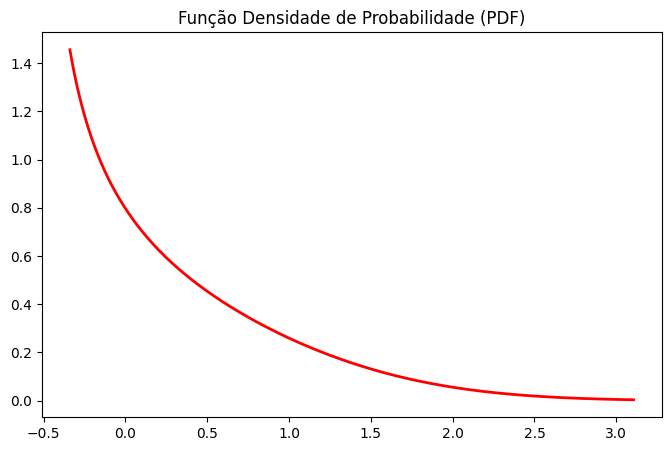

In [102]:
pdf_vals = g.pdf(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, pdf_vals, color='red', lw=2)
plt.title('Função Densidade de Probabilidade (PDF)')

plt.savefig('02_grafico_pdf.png', dpi=300, bbox_inches='tight')

plt.show()

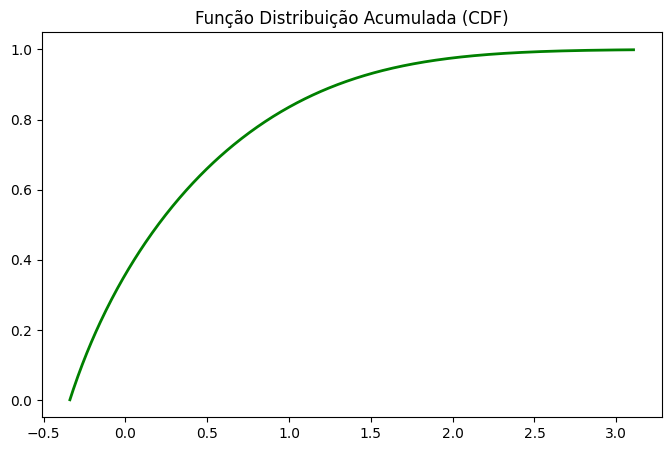

In [103]:
cdf_vals = g.cdf(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, cdf_vals, color='green', lw=2)
plt.title('Função Distribuição Acumulada (CDF)')

plt.savefig('03_grafico_cdf.png', dpi=300, bbox_inches='tight')

plt.show()

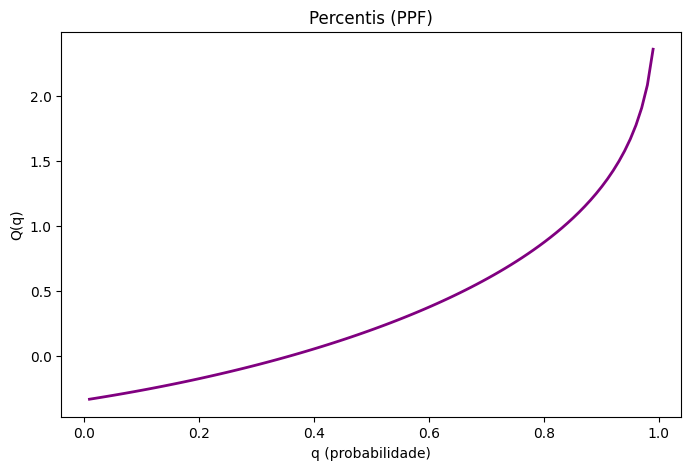

In [104]:
q_vals = np.linspace(0.01, 0.99, 100)
ppf_vals = g.ppf(q_vals)

plt.figure(figsize=(8, 5))
plt.plot(q_vals, ppf_vals, color='purple', lw=2)
plt.title('Percentis (PPF)')
plt.xlabel('q (probabilidade)')
plt.ylabel('Q(q)')


plt.savefig('04_grafico_ppf.png', dpi=300, bbox_inches='tight')

plt.show()

#### 2° Instância: Gráfico Parabólico

In [105]:
# 1. Instanciar a distribuição com os lambdas escolhidos
lam1, lam2, lam3, lam4 = 0.00251029, 1.45848339, 0.13177565, 0.13239563
g = GlamFKML(lam1=lam1, lam2=lam2, lam3=lam3, lam4=lam4)

# 2. Gerar Amostra (RVS)
amostra = g.rvs(size=1000)

# 3. Gerar valores do eixo X para a PDF e CDF
x_vals = np.linspace(min(amostra), max(amostra), 500)

# 4. Calcular PDF e CDF
pdf_vals = g.pdf(x_vals)
cdf_vals = g.cdf(x_vals)

# 5. Calcular Percentis (PPF)
q_vals = np.linspace(0.01, 0.99, 100)
ppf_vals = g.ppf(q_vals)

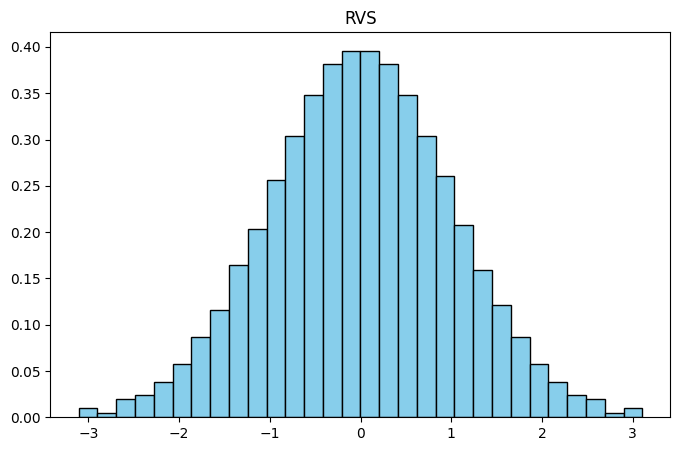

In [106]:
plt.figure(figsize=(8, 5))
plt.hist(amostra, bins=30, density=True, color='skyblue', edgecolor='black')
plt.title('RVS')            

plt.savefig('01_histograma_amostra.png', dpi=300, bbox_inches='tight')

plt.show()

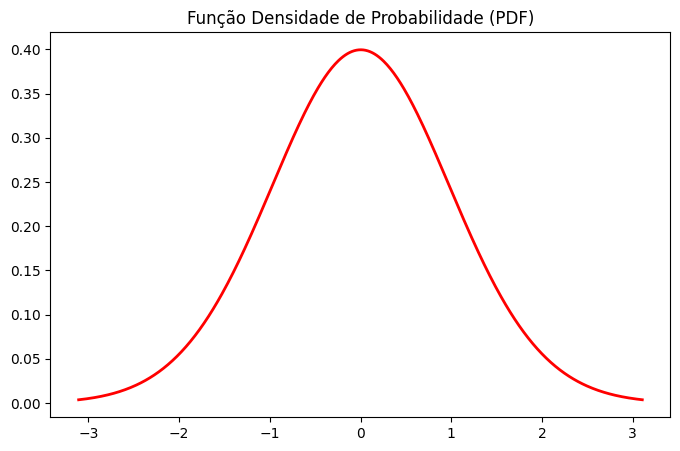

In [107]:
plt.figure(figsize=(8, 5))
plt.plot(x_vals, pdf_vals, color='red', lw=2)
plt.title('Função Densidade de Probabilidade (PDF)')

plt.savefig('02_grafico_pdf.png', dpi=300, bbox_inches='tight')

plt.show()

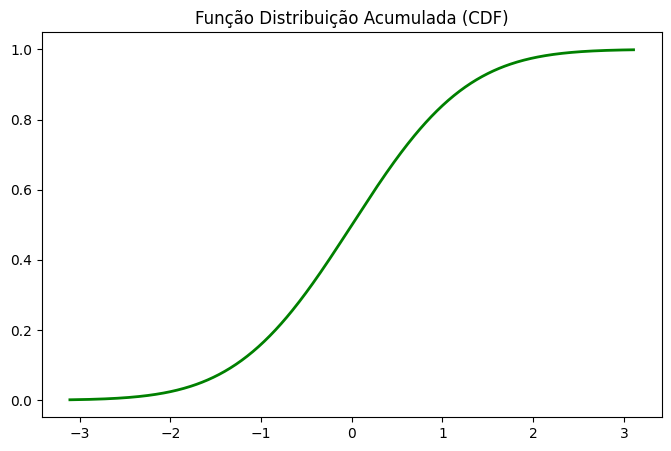

In [108]:
cdf_vals = g.cdf(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, cdf_vals, color='green', lw=2)
plt.title('Função Distribuição Acumulada (CDF)')

plt.savefig('03_grafico_cdf.png', dpi=300, bbox_inches='tight')

plt.show()

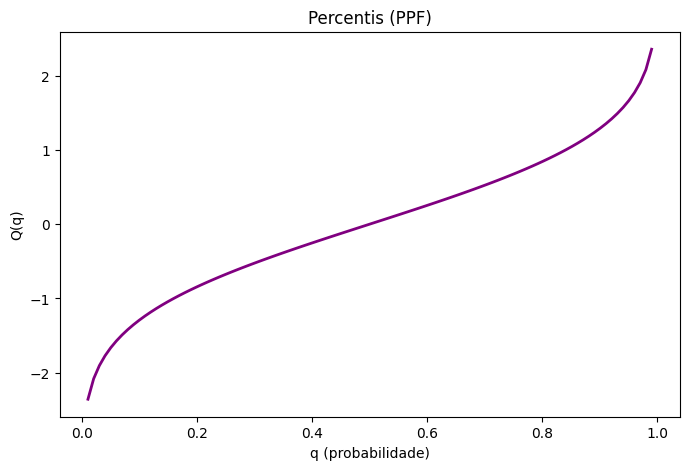

In [109]:
ppf_vals = g.ppf(q_vals)

plt.figure(figsize=(8, 5))
plt.plot(q_vals, ppf_vals, color='purple', lw=2)
plt.title('Percentis (PPF)')
plt.xlabel('q (probabilidade)')
plt.ylabel('Q(q)')

plt.savefig('04_grafico_ppf.png', dpi=300, bbox_inches='tight')

plt.show()

### Ajuste em Distribuição Normal

Agora, vamos testar a capacidade de imitar uma Distribuição Normal. 

O processo será:
1. Gerar dados de uma Normal Padrão (média 0, desvio 1).
2. Usar o método `fit_lambdas` para encontrar a combinação perfeita dos 4 parâmetros que desenham essa curva.
3. Alterar um parâmetro de cada vez para vermos, na prática, como eles deformam a distribuição simétrica.

### 1. Gerando Dados e Encontrando os Lambdas Base
Aqui geramos a nossa amostra normal e pedimos à biblioteca para encontrar os valores ideais dos lambdas (`lambdas_base`). Também criamos a função que vai multiplicar esses valores por 0.5 (metade), 1.0 (original) e 1.5 (aumento de 50%) para vermos as mudanças.

In [110]:
# 1. Gerar dados de uma distribuição Normal padrão
dados_normais = np.random.normal(loc=0, scale=1, size=5000)

# 2. Ajustar a GLAM-FKML aos dados normais
g_fit = GlamFKML()
sol = g_fit.fit_lambdas(dados_normais, method="least_squares")
lambdas_base = sol.x
print(f"Lambdas ajustados para Normal: {lambdas_base}")

# 3. Função para variar um lambda e plotar o comportamento
def plot_variacao_lambda(lambdas, indice, multiplicadores, titulo):
    plt.figure(figsize=(8, 5))
    
    for mult in multiplicadores:
        # Copia os lambdas base e aplica a modificação
        lambdas_mod = list(lambdas)
        lambdas_mod[indice] *= mult
        
        # Gera nova distribuição e amostra
        g_mod = GlamFKML(*lambdas_mod)
        amostra_mod = g_mod.rvs(size=1000)
        
        plt.hist(amostra_mod, bins=30, density=True, alpha=0.5, 
                 label=f'Lambda {indice+1} = {lambdas_mod[indice]:.4f}')
        
    plt.title(titulo)
    plt.legend()
    plt.show()

# Multiplicadores para testar: 50% do valor, o valor original (1.0), e 150% do valor
multiplicadores = [0.5, 1.0, 1.5]

Lambdas ajustados para Normal: [0.00680389 1.4412483  0.13963498 0.1465484 ]


### Lambda 1
O $\lambda_1$ controla a **posição** da curva no eixo X.
A curva deve manter exatamente o mesmo formato, mas deslizar para a esquerda ou para a direita, dependendo do multiplicador.

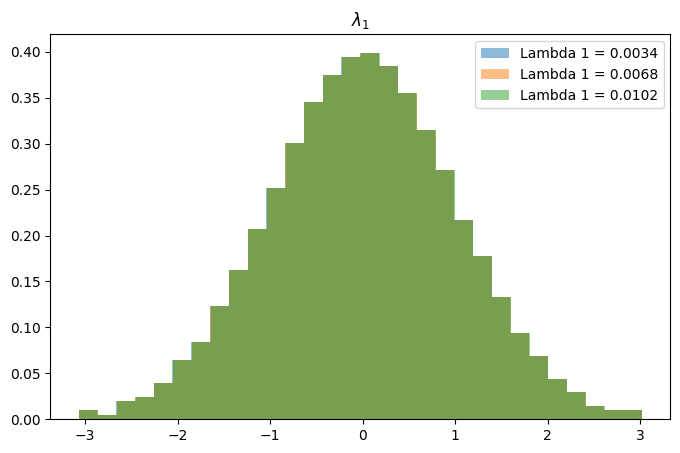

<Figure size 640x480 with 0 Axes>

In [111]:
plot_variacao_lambda(lambdas_base, 0, multiplicadores, "$\lambda_1$")
plt.savefig('01_grafico_variacao_lambda1.png', dpi=300, bbox_inches='tight')

### Lambda 2
O $\lambda_2$ controla a **largura** (dispersão) da curva. Multiplicadores menores devem deixar a curva mais "fina e alta" (menor variância), enquanto multiplicadores maiores vão deixá-la mais "larga e achatada" (maior variância).

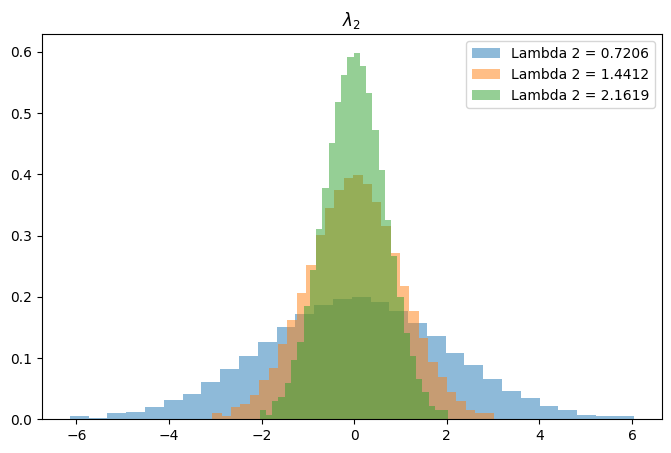

<Figure size 640x480 with 0 Axes>

In [112]:
plot_variacao_lambda(lambdas_base, 1, multiplicadores, "$\lambda_2$")
plt.savefig('02_grafico_variacao_lambda2.png', dpi=300, bbox_inches='tight')

### Lambda 3
O Lambda 3 controla o peso do **lado esquerdo** da distribuição. Como a Normal é perfeitamente simétrica, mexer neste parâmetro vai quebrar essa simetria, encurtando ou alongando a cauda apenas do lado esquerdo do gráfico.

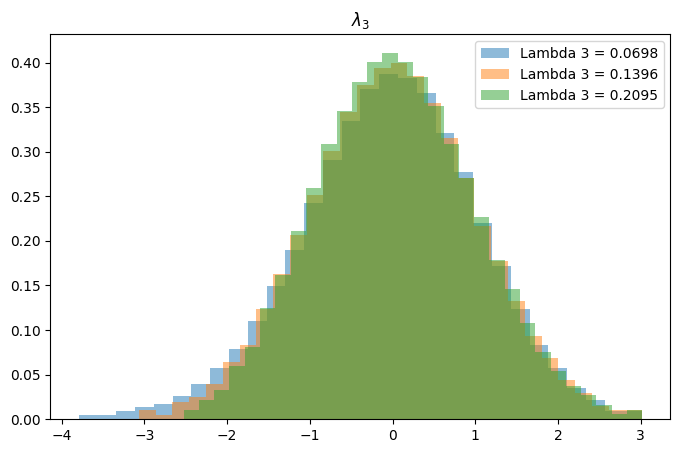

<Figure size 640x480 with 0 Axes>

In [113]:
plot_variacao_lambda(lambdas_base, 2, multiplicadores, "$\lambda_3$")
plt.savefig('03_grafico_variacao_lambda3.png', dpi=300, bbox_inches='tight')

### Lambda 4
O Lambda 4 controla o peso do **lado direito** da distribuição. Semelhante ao Lambda anterior, mas a distorção (assimetria) acontecerá exclusivamente no lado direito do gráfico.

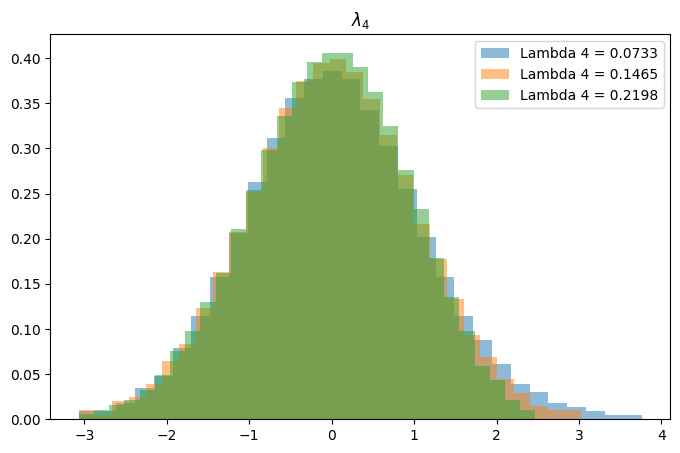

<Figure size 640x480 with 0 Axes>

In [114]:
plot_variacao_lambda(lambdas_base, 3, multiplicadores, "$\lambda_4$")
plt.savefig('04_grafico_variacao_lambda4.png', dpi=300, bbox_inches='tight')

# Ajuste em Distribuição Gumbel

Por fim, vamos testar a capacidade de imitar uma Distribuição Gumbel. Diferente da Normal, a Gumbel é **assimétrica** e muito utilizada para prever eventos extremos (como picos de enchentes ou falhas em equipamentos).

O processo será:
1. Gerar dados de uma Gumbel padrão (com assimetria à direita).
2. Usar o método `fit_lambdas` para encontrar a combinação ideal dos 4 parâmetros.
3. Alterar um parâmetro de cada vez para observarmos como eles afetam uma curva que já é naturalmente distorcida.

### Gerando Dados e Encontrando os Lambdas Base
Nesta etapa, geramos a amostra Gumbel e deixamos o modelo calcular os `lambdas_base`. Como a Gumbel tem uma cauda longa à direita, é esperado que o modelo encontre valores bem diferentes para o $\lambda_3$ e o $\lambda_4$ (quebrando a simetria). Também preparamos a função de plotagem.

In [115]:
# 1. Gerar dados de uma distribuição Gumbel
dados_gumbel = np.random.gumbel(loc=4, scale=1, size=5000)

# 2. Ajustar a GLAM-FKML aos dados Gumbel
g_fit = GlamFKML()
sol = g_fit.fit_lambdas(dados_gumbel, method="least_squares")
lambdas_base = sol.x
print(f"Lambdas ajustados para Gumbel: {lambdas_base}")

# 3. Função para variar um lambda e plotar o comportamento
def plot_variacao_lambda(lambdas, indice, multiplicadores, titulo):
    plt.figure(figsize=(8, 5))
    
    for mult in multiplicadores:
        lambdas_mod = list(lambdas)
        lambdas_mod[indice] *= mult
        
        g_mod = GlamFKML(*lambdas_mod)
        amostra_mod = g_mod.rvs(size=1000)
        
        plt.hist(amostra_mod, bins=30, density=True, alpha=0.5, 
                 label=f'Lambda {indice+1} = {lambdas_mod[indice]:.4f}')
        
    plt.title(titulo)
    plt.legend()
    plt.show()

multiplicadores = [0.5, 1.0, 1.5]

Lambdas ajustados para Gumbel: [ 4.28461912  1.25842531  0.36841107 -0.08073041]


### Lambda 1
O $\lambda_1$ controla a **posição** da curva. O formato assimétrico da Gumbel deve permanecer intacto, com o gráfico apenas a deslocar-se para a esquerda ou para a direita no eixo X.

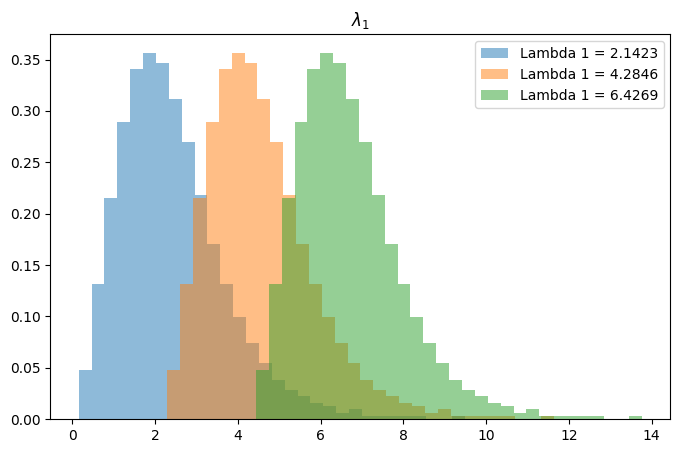

<Figure size 640x480 with 0 Axes>

In [116]:
plot_variacao_lambda(lambdas_base, 0, multiplicadores, "$\lambda_1$")
plt.savefig('01_grafico_variacao_gumbel_lambda1.png', dpi=300, bbox_inches='tight')

### Lambda 2
O $\lambda_2$ controla a **dispersão** (largura) da curva. Valores menores comprimem a curva (pico mais alto e estreito), enquanto valores maiores a esticam horizontalmente. A assimetria geral mantém-se, mas em proporções diferentes.

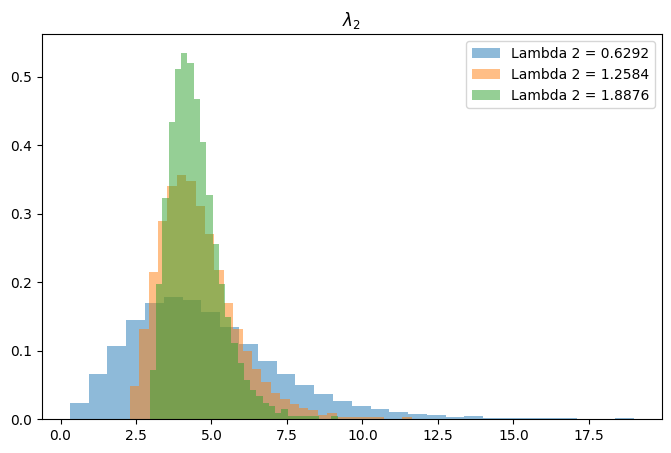

<Figure size 640x480 with 0 Axes>

In [117]:
plot_variacao_lambda(lambdas_base, 1, multiplicadores, "$\lambda_2$")
plt.savefig('02_grafico_variacao_gumbel_lambda2.png', dpi=300, bbox_inches='tight')

### Lambda 3
O $\lambda_3$ afeta exclusivamente o **lado esquerdo** do gráfico. Como a Gumbel original "nasce" de forma mais abrupta do lado esquerdo, mexer neste parâmetro vai alterar o quão rápido a curva sobe até atingir o seu pico.

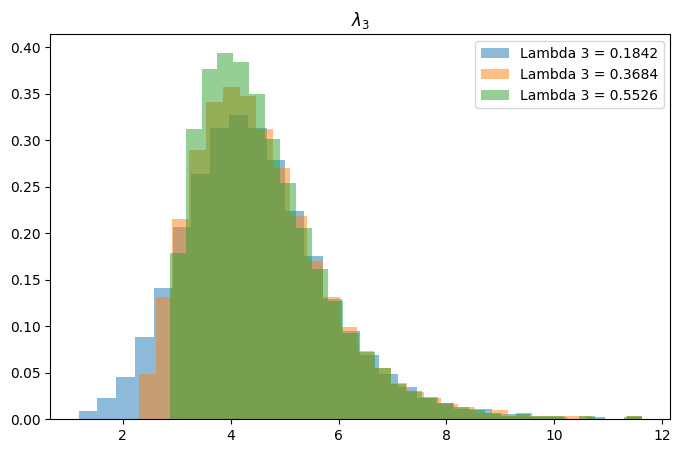

<Figure size 640x480 with 0 Axes>

In [118]:
plot_variacao_lambda(lambdas_base, 2, multiplicadores, "$\lambda_3$")
plt.savefig('03_grafico_variacao_gumbel_lambda3.png', dpi=300, bbox_inches='tight')

### Lambda 4
O $\lambda_4$ afeta exclusivamente o **lado direito** do gráfico. Alterar o $\lambda_4$ vai encurtar ou esticar ainda mais o lado direito da distribuição, mudando drasticamente o peso dos eventos extremos.

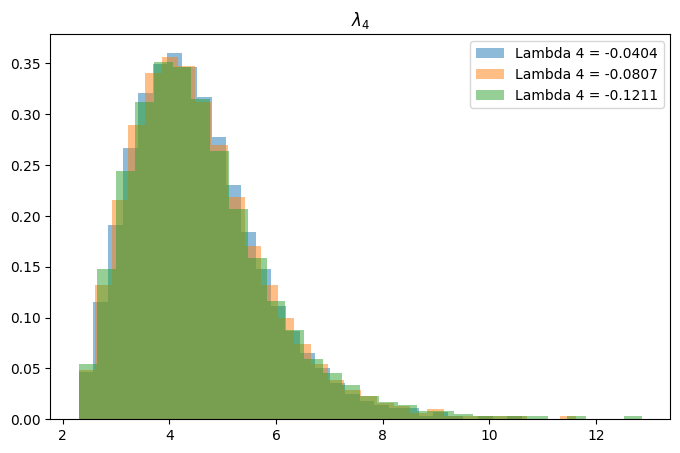

<Figure size 640x480 with 0 Axes>

In [119]:
plot_variacao_lambda(lambdas_base, 3, multiplicadores, "$\lambda_4$")
plt.savefig('04_grafico_variacao_gumbel_lambda4.png', dpi=300, bbox_inches='tight')